In [1]:
from configs import load_config
from imports import *

Check brightness of training data

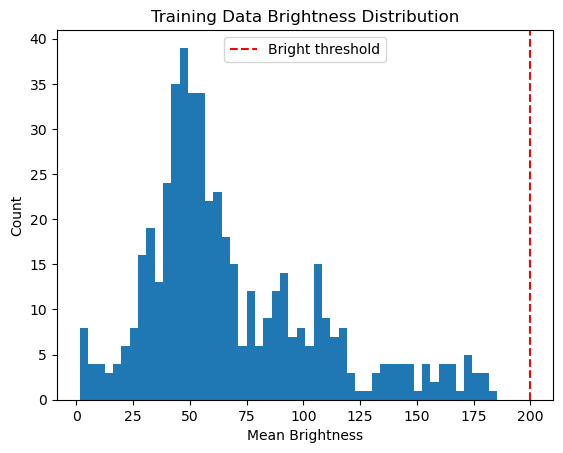

Bright images (>150): 5.6%
Dark images (<50): 37.2%


In [2]:
config = load_config(path="../configs/default.yaml")
cropped_dir = Path(config.paths.cropped_img_root) / "cropped_gt"
brightness_values = []

for img_path in list(cropped_dir.glob("*.png"))[:500]:
    img = np.array(Image.open(img_path))
    brightness_values.append(img.mean())

plt.hist(brightness_values, bins=50)
plt.xlabel("Mean Brightness")
plt.ylabel("Count")
plt.title("Training Data Brightness Distribution")
plt.axvline(200, color='r', linestyle='--', label="Bright threshold")
plt.legend()
plt.show()

print(f"Bright images (>150): {sum(b > 150 for b in brightness_values) / len(brightness_values) * 100:.1f}%")
print(f"Dark images (<50): {sum(b < 50 for b in brightness_values) / len(brightness_values) * 100:.1f}%")
